In [13]:
# PyTorch core
import sys
import torch  # Main PyTorch library for tensors and operations
import os

# NumPy and Pandas for data manipulation
import numpy as np  # For numerical operations
import pandas as pd  # For handling tabular data (DataFrames)

# Matplotlib for visualization
import matplotlib.pyplot as plt  # For plotting graphs

# Time tracking
import time  # For measuring training or execution time

# PyTorch neural network and optimization modules
import torch.nn as nn  # To define neural network layers and architectures
import torch.optim as optim  # For optimization algorithms like SGD, Adam, etc.

# PyTorch utilities for dataset handling
from torch.utils.data import DataLoader, TensorDataset  # For batching and shuffling data

# Progress bar for loops
from tqdm.notebook import tqdm, trange  # For displaying progress bars in notebooks

# Data preprocessing
from sklearn.preprocessing import StandardScaler  # For feature normalization (zero mean, unit variance)

# Load California housing dataset
from sklearn.datasets import fetch_california_housing  # Fetch the dataset used for regression

# Train/validation/test splitting
from sklearn.model_selection import train_test_split  # For splitting the dataset into train/val/test


# 🧠 Tropical Neural Network for California Housing Price Regression

## 📘 Project Overview

This notebook explores the application of **tropical algebra** within a custom neural network to predict **housing prices** using the **California Housing dataset**.

While traditional neural networks rely on standard linear algebra operations followed by common activation functions (like ReLU, tanh, or sigmoid), this project introduces a novel approach where:

- The **pre-activation transformation** (i.e., the operation before applying an activation function) is based on **tropical algebra**, specifically using the **max-plus semiring**.
- The **training process**, however, still leverages standard optimization techniques (e.g., **backpropagation**, **stochastic gradient descent**, **MSE loss**), allowing integration into PyTorch's automatic differentiation framework.

## 🌴 What Is Tropical Algebra?

Tropical algebra is a mathematical structure where:

- **Addition** becomes `max(a, b)`
- **Multiplication** becomes `a + b`

This algebraic framework has unique properties that make it useful in:
- Discrete optimization
- Scheduling problems
- Control theory
- Tropical geometry
- Linearity in tropical domain

In our context, we reinterpret dense layers using tropical linear operations to model the network's transformations.

## 🎯 Objective

The goal is to assess whether tropical transformations can serve as a useful **nonlinear mechanism** in regression models, specifically to:

- Replace the traditional affine transformation in neural layers with tropical algebra
- Retain gradient-based optimization to fit the model to real-world data
- Benchmark the performance against standard architectures (in future work)
- Validate properties of the tropical neural network using the tropical simplex (in future work)

## 🏗️ Implementation Plan

1. **Load and preprocess** the California Housing dataset.
2. **Define a custom neural layer** that implements tropical operations (e.g., tropical matrix-vector product).
3. **Stack tropical layers** into a feed-forward architecture.
4. **Train the model** using MSE loss and Adam optimizer.
5. **Evaluate performance** on validation and test sets.


## 1. Data Loading and Preprocessing

In [2]:
# --------------------------------------------------
# 1. Load Dataset (California Housing for Regression)
# --------------------------------------------------
data = fetch_california_housing()

# Description of the features:
# 1. longitude: A measure of how far west a house is; a higher value is farther west
# 2. latitude: A measure of how far north a house is; a higher value is farther north
# 3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
# 4. totalRooms: Total number of rooms within a block
# 5. totalBedrooms: Total number of bedrooms within a block
# 6. population: Total number of people residing within a block
# 7. households: Total number of households (groups of people residing in a housing unit) for a block
# 8. medianIncome: Median income for households within a block (measured in tens of thousands of US Dollars)
# 9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
# 10. oceanProximity: Location of the house with respect to the ocean/sea

# Prepare the features and target
X_all_features = data.data
y_ch = data.target.reshape(-1, 1)
feature_names_ch = data.feature_names

# Create a DataFrame to easily select features by name
df_ch = pd.DataFrame(X_all_features, columns=feature_names_ch)

# --------------------------------------------------
# 2. Split the data into train, validation, and test sets
# --------------------------------------------------
X_train_ch, X_temp_ch, y_train_ch, y_temp_ch = train_test_split(
    X_all_features, y_ch, test_size=0.3, random_state=42
)
X_val_ch, X_test_ch, y_val_ch, y_test_ch = train_test_split(
    X_temp_ch, y_temp_ch, test_size=0.5, random_state=42
)

# --------------------------------------------------
# 3. Scale the numerical features using StandardScaler
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ch)
X_val_scaled = scaler.transform(X_val_ch)
X_test_scaled = scaler.transform(X_test_ch)

# --------------------------------------------------
# 4. Convert data to PyTorch tensors
# --------------------------------------------------
X_train = torch.from_numpy(X_train_scaled).float()
X_val   = torch.from_numpy(X_val_scaled).float()
X_test  = torch.from_numpy(X_test_scaled).float()

y_train = torch.from_numpy(y_train_ch).float()
y_val   = torch.from_numpy(y_val_ch).float()
y_test  = torch.from_numpy(y_test_ch).float()

# --------------------------------------------------
# 5. Useful dimensions for the model
# --------------------------------------------------
num_input_features = X_train.shape[1]
output_size_regression = y_train.shape[1]

print(f"• Number of input features: {num_input_features}")
print(f"• Output size (regression): {output_size_regression}")

# --------------------------------------------------
# 6. Create TensorDataset and DataLoader
# --------------------------------------------------
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

batch_size = 32  # You can adjust this batch size if needed

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

• Number of input features: 8
• Output size (regression): 1


## 2. Tropical MLP Implementation

In [3]:
class TropLayer(nn.Module):
    """
    A custom linear layer using tropical (max-plus) algebra.
    
    In tropical algebra:
      - "addition" is replaced by max(a, b)
      - "multiplication" is replaced by a + b

    This layer computes the tropical matrix-vector product:
        (Wx)_i = max_j (W_ij + x_j), followed by:
        - bias max: max(trop_output, bias)
        - ReLU-like cutoff: max(trop_output, 0)
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # Initialize weights with negative values to enforce sparsity
        self.W = nn.Parameter(-0.5 * torch.abs(torch.randn(out_features, in_features)))
        
        # Very low bias values initially (inactive)
        self.b = nn.Parameter(torch.full((out_features,), -1e4))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Compute all W_ij + x_j (broadcasting over batch)
        z_all = self.W.unsqueeze(0) + x.unsqueeze(1)  # Shape: (batch, out_features, in_features)
        
        # Tropical matrix-vector product: max over input dimension
        z_trop, _ = torch.max(z_all, dim=2)  # Shape: (batch, out_features)

        # Add tropical bias: max(z, b)
        z_trop = torch.max(z_trop, self.b.unsqueeze(0))  # Shape: (batch, out_features)

        # Apply ReLU-like activation: max(z, 0)
        z_trop = torch.max(z_trop, torch.zeros_like(z_trop))

        return z_trop


class TropMLP(nn.Module):
    """
    A tropical MLP (multi-layer perceptron) that stacks multiple TropLayers.
    
    Parameters:
        - input_size: number of input features
        - output_size: number of outputs (1 for regression)
        - hidden_size: number of units in each hidden layer
        - num_layers: total number of tropical layers (≥1)
    """
    def __init__(self, input_size: int, output_size: int, hidden_size: int = 128, num_layers: int = 1):
        super().__init__()
                
        # First hidden layer: from input features to hidden representation
        self.first_hidden = TropLayer(input_size, hidden_size)

        # Hidden layers (optional)
        self.hidden_layers = nn.ModuleList([
            TropLayer(hidden_size, hidden_size) for _ in range(num_layers - 1)
        ])

        # Output layer
        self.outputlay = TropLayer(hidden_size, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.first_hidden(x)
            for layer in self.hidden_layers:
                x = layer(x)
            x = self.outputlay(x)
            return x

## 3. Definition of Training, Validation, and Testing Modules

### 3.1 Training

In [4]:
def train(model, iterator, optimizer, criterion):
    """
    Trains the model for one epoch using the provided data iterator.

    Args:
        model: the neural network model (e.g., TropMLP)
        iterator: DataLoader that yields batches of (x, y) for training
        optimizer: optimization algorithm (e.g., Adam)
        criterion: loss function (e.g., nn.MSELoss)

    Returns:
        train_loss: weighted average loss over all training examples
    """
    epoch_loss = 0.0
    total_examples = 0

    model.train()  # Set model to training mode

    for (x, y) in tqdm(iterator, desc="Training", leave=False):
        optimizer.zero_grad()         # Reset gradients
        predictions = model(x)        # Forward pass

        loss = criterion(predictions, y)  # Compute loss
        loss.backward()              # Backpropagation
        optimizer.step()             # Update parameters

        batch_size = x.size(0)
        total_examples += batch_size
        epoch_loss += loss.item() * batch_size  # Weighted loss sum

    train_loss = epoch_loss / total_examples
    return train_loss


### 3.2 Validation

In [5]:
def validate(model, iterator, mse_loss_fn):
    """
    Evaluates the model on a validation set and returns the average MSE.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the validation data
        mse_loss_fn: instance of torch.nn.MSELoss()

    Returns:
        avg_mse: mean squared error averaged over all validation examples
    """
    model.eval()  # Set model to evaluation mode
    total_mse = 0.0
    total_examples = 0

    with torch.no_grad():  # Disable gradient computation
        for x, y in tqdm(iterator, desc="Validating", leave=False):
            predictions = model(x)                  # Forward pass
            mse = mse_loss_fn(predictions, y)       # Compute MSE
            batch_size = x.size(0)
            total_mse += mse.item() * batch_size    # Accumulate weighted MSE
            total_examples += batch_size

    avg_mse = total_mse / total_examples
    return avg_mse

### 3.3 Test Evaluation

In [6]:
def evaluate_test(model, iterator, mse_loss_fn, mae_loss_fn):
    """
    Evaluates the model on a test DataLoader and returns MSE, MAE, and RMSE.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the test data
        mse_loss_fn: instance of torch.nn.MSELoss()
        mae_loss_fn: instance of torch.nn.L1Loss()

    Returns:
        eval_mse: average Mean Squared Error (MSE)
        eval_mae: average Mean Absolute Error (MAE)
        eval_rmse: Root Mean Squared Error (RMSE) computed from the MSE
    """
    model.eval()  # Set model to evaluation mode
    total_mse = 0.0
    total_mae = 0.0
    total_examples = 0

    with torch.no_grad():  # Disable gradient computation
        for x, y in tqdm(iterator, desc="Testing", leave=False):
            predictions = model(x)                    # Forward pass
            batch_size = x.size(0)

            mse = mse_loss_fn(predictions, y)         # Compute MSE
            mae = mae_loss_fn(predictions, y)         # Compute MAE

            total_mse += mse.item() * batch_size      # Accumulate weighted MSE
            total_mae += mae.item() * batch_size      # Accumulate weighted MAE
            total_examples += batch_size

    eval_mse = total_mse / total_examples
    eval_mae = total_mae / total_examples
    eval_rmse = np.sqrt(eval_mse)

    return eval_mse, eval_mae, eval_rmse

## 4. Setup and Configuration

In [7]:
def epoch_time(start_time, end_time):
    """
    Calculates elapsed time between start and end timestamps.

    Args:
        start_time: float, start time in seconds
        end_time: float, end time in seconds

    Returns:
        elapsed_mins: integer number of minutes
        elapsed_secs: remaining seconds (after minutes are accounted for)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time // 60)
    elapsed_secs = int(elapsed_time % 60)
    return elapsed_mins, elapsed_secs

In [8]:
# Instantiate the TropMLP model with specified parameters
model = TropMLP(
    input_size=num_input_features,    # Number of input features
    hidden_size=128,                  # Size of hidden layers
    output_size=output_size_regression,  # Output size (1 for regression)
    num_layers=3                     # Number of TropLayer hidden layers
)

# Define Mean Squared Error as loss function for regression
criterion = nn.MSELoss()

# Use Adam optimizer with learning rate 0.03
optimizer = optim.Adam(model.parameters(), lr=3e-2)

## 5. Training and Validation Loop

In [9]:
EPOCHS = 50
best_valid_loss = float('inf')
results_Regression = []

for epoch in trange(EPOCHS, desc="Epochs"):
    start_time = time.monotonic()

    # Train for one epoch
    train_loss = train(model, train_loader, optimizer, criterion)

    # Validate model on validation set (MSE only)
    valid_loss = validate(model, valid_loader, criterion)

    # Save model if validation loss improves
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tropical-regression-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Store losses for later analysis
    results_Regression.append({
        "Train Loss": train_loss,
        "Valid Loss": valid_loss,
    })

    # Print epoch statistics
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f}')
    print(f'\tValid Loss (MSE): {valid_loss:.3f}')

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/452 [00:00<?, ?it/s]

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 2s
	Train Loss: 2.614
	Valid Loss (MSE): 1.144


Training:   0%|          | 0/452 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 49 | Epoch Time: 0m 2s
	Train Loss: 1.634
	Valid Loss (MSE): 0.767


Training:   0%|          | 0/452 [00:00<?, ?it/s]

Validating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch: 50 | Epoch Time: 0m 2s
	Train Loss: 1.633
	Valid Loss (MSE): 0.799


In [20]:
model_path = 'tropical-regression-model.pt'
model.load_state_dict(torch.load(model_path))
model.eval() # Mettilo in modalità valutazione

layer1_W = model.first_hidden.W.detach().numpy()
layer1_b = model.first_hidden.b.detach().numpy()

hidden_layers_W = [layer.W.detach().numpy() for layer in model.hidden_layers]
hidden_layers_b = [layer.b.detach().numpy() for layer in model.hidden_layers]

output_layer_W = model.outputlay.W.detach().numpy()
output_layer_b = model.outputlay.b.detach().numpy()

print(f"Pesi caricati dal modello '{model_path}'")
print(f"  Layer 1 (first_hidden) W: {layer1_W.shape}")
print(f"  Layer 1 (first_hidden) b: {layer1_b.shape}")
for i in range(len(hidden_layers_W)):
    print(f"  Layer {i+2} (hidden) W: {hidden_layers_W[i].shape}")
    print(f"  Layer {i+2} (hidden) b: {hidden_layers_b[i].shape}")
print(f"  Layer Output W: {output_layer_W.shape}")
print(f"  Layer Output b: {output_layer_b.shape}")

# --- 3. Salvataggio dei Pesi su File di Testo ---

# Create a directory to store the weights
output_dir = "model_weights"
os.makedirs(output_dir, exist_ok=True)
print(f"\nSalvataggio dei pesi in formato .txt nella cartella '{output_dir}'...")

# Set print options to save the full arrays
np.set_printoptions(threshold=sys.maxsize)

# Save Layer 1
np.savetxt(os.path.join(output_dir, "layer1_W.csv"), layer1_W, fmt="%.18e", delimiter=",")
np.savetxt(os.path.join(output_dir, "layer1_b.csv"), layer1_b, fmt="%.18e", delimiter=",")

# Save Hidden Layers
for i in range(len(hidden_layers_W)):
    np.savetxt(os.path.join(output_dir, f"layer{i+2}_hidden_W.csv"), hidden_layers_W[i], fmt="%.18e", delimiter=",")
    np.savetxt(os.path.join(output_dir, f"layer{i+2}_hidden_b.csv"), hidden_layers_b[i], fmt="%.18e", delimiter=",")

# Save Output Layer
np.savetxt(os.path.join(output_dir, "output_layer_W.csv"), output_layer_W, fmt="%.18e", delimiter=",")
np.savetxt(os.path.join(output_dir, "output_layer_b.csv"), output_layer_b, fmt="%.18e", delimiter=",")

print("Salvataggio completato.")
print("Ora puoi ispezionare i file .csv per vedere tutti i coefficienti numerici.")

Pesi caricati dal modello 'tropical-regression-model.pt'
  Layer 1 (first_hidden) W: (128, 8)
  Layer 1 (first_hidden) b: (128,)
  Layer 2 (hidden) W: (128, 128)
  Layer 2 (hidden) b: (128,)
  Layer 3 (hidden) W: (128, 128)
  Layer 3 (hidden) b: (128,)
  Layer Output W: (1, 128)
  Layer Output b: (1,)

Salvataggio dei pesi in formato .txt nella cartella 'model_weights'...
Salvataggio completato.
Ora puoi ispezionare i file .csv per vedere tutti i coefficienti numerici.


C:\Users\aless\AppData\Local\Temp\ipykernel_12160\3254579734.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


## 6. Results

### 6.1 Training and Validation Loss Curves

In [16]:
def plot_results(results):
    """
    Plots training and validation loss over epochs.

    Args:
        results: pandas DataFrame with columns 'Train Loss' and 'Valid Loss', indexed by epoch
    """

    # Plot Training Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Train Loss'], label='Train Loss', marker='o')
    plt.title('Training Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Plot Validation Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Valid Loss'], label='Valid Loss', marker='s', color='orange')
    plt.title('Validation Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
# Convert list of dicts to DataFrame
results_Tropical = pd.DataFrame(results_Regression)

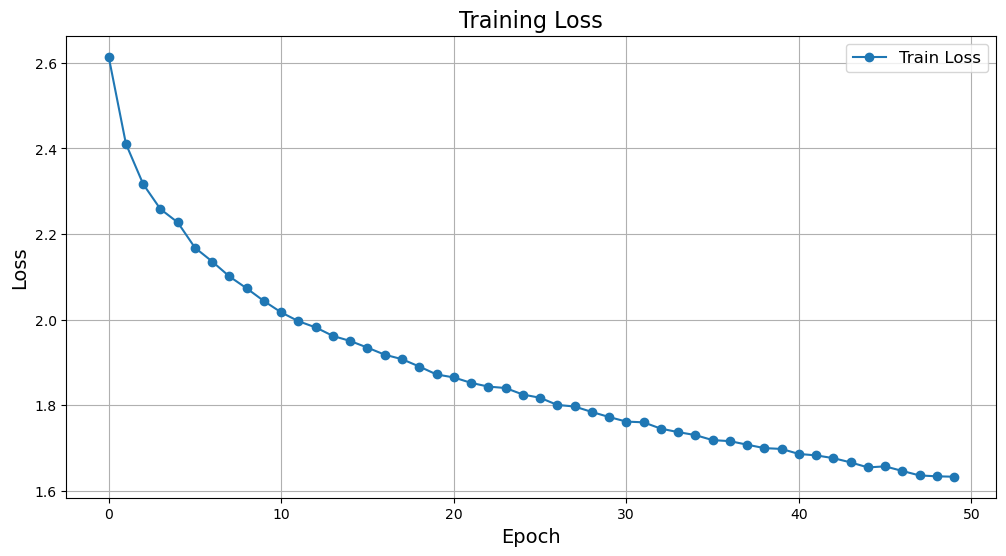

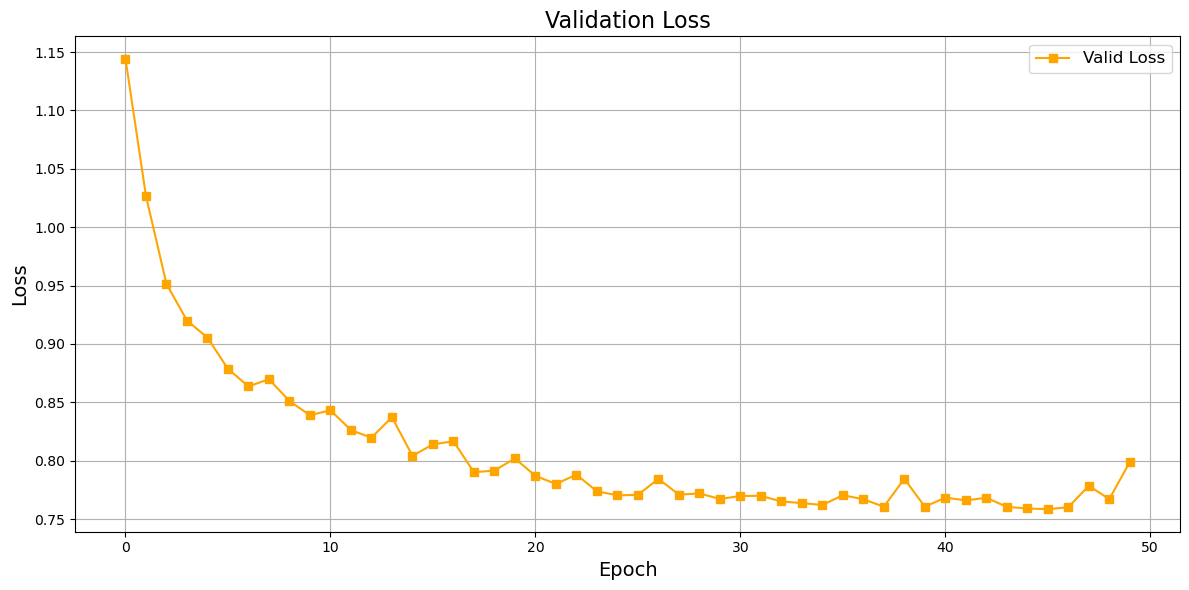

In [18]:
plot_results(results_Tropical)

### Test Results

In [13]:
# Load the best saved model weights
model.load_state_dict(torch.load('tropical-regression-model.pt'))

# Evaluate the model on the test set
test_mse, test_mae, test_rmse = evaluate_test(model, test_loader, nn.MSELoss(), nn.L1Loss())

print("\n--- Test Results ---")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

Testing:   0%|          | 0/97 [00:00<?, ?it/s]


--- Test Results ---
Test MSE  : 1.7369
Test MAE  : 0.6377
Test RMSE : 1.3179
